In [1]:
from google.colab import drive
drive.mount('/content/drive')
%cd /content/drive/MyDrive/TELCO_CHURN_PROJECT

Mounted at /content/drive
/content/drive/MyDrive/TELCO_CHURN_PROJECT


In [2]:
!pip install -q xgboost

In [3]:
from pathlib import Path
import json
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, RandomizedSearchCV, StratifiedKFold
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report,
    fbeta_score
)

from xgboost import XGBClassifier

warnings.filterwarnings("ignore")
pd.set_option("display.max_columns", None)

In [4]:
# =====================================================
# PATH CONFIG
# =====================================================
def get_project_root() -> Path:
    return Path.cwd().resolve().parent if Path.cwd().name == "notebooks" else Path.cwd().resolve()


PROJECT_ROOT = get_project_root()

DATA_PROCESSED_DIR = PROJECT_ROOT / "data" / "processed"
DATA_FE_DIR = PROJECT_ROOT / "data" / "feature_engineering" / "xgboost"
OUTPUT_DIR = PROJECT_ROOT / "outputs" / "xgboost"

DATA_FE_DIR.mkdir(parents=True, exist_ok=True)
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

CLEAN_FILE = DATA_PROCESSED_DIR / "telco_churn_clean.csv"

print("PROJECT_ROOT:", PROJECT_ROOT)
print("CLEAN_FILE:", CLEAN_FILE)
print("DATA_FE_DIR:", DATA_FE_DIR)
print("OUTPUT_DIR:", OUTPUT_DIR)

PROJECT_ROOT: /content/drive/MyDrive/TELCO_CHURN_PROJECT
CLEAN_FILE: /content/drive/MyDrive/TELCO_CHURN_PROJECT/data/processed/telco_churn_clean.csv
DATA_FE_DIR: /content/drive/MyDrive/TELCO_CHURN_PROJECT/data/feature_engineering/xgboost
OUTPUT_DIR: /content/drive/MyDrive/TELCO_CHURN_PROJECT/outputs/xgboost


In [5]:
# =====================================================
# LOAD DATA
# =====================================================
if not CLEAN_FILE.exists():
    raise FileNotFoundError(f"Không tìm thấy file clean: {CLEAN_FILE}")

df_base = pd.read_csv(CLEAN_FILE)

if "Churn" not in df_base.columns:
    raise ValueError("File clean phải có cột 'Churn'")

print("Shape:", df_base.shape)
display(df_base.head())

Shape: (7032, 20)


,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.50,No
2,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [6]:
# =====================================================
# FEATURE ENGINEERING FOR XGBOOST
# =====================================================
def add_common_features(df: pd.DataFrame) -> pd.DataFrame:
    df = df.copy()

    required_cols = [
        "tenure", "MonthlyCharges", "TotalCharges", "SeniorCitizen",
        "OnlineSecurity", "OnlineBackup", "DeviceProtection", "TechSupport",
        "StreamingTV", "StreamingMovies",
        "Contract", "PaymentMethod"
    ]

    missing_cols = [col for col in required_cols if col not in df.columns]
    if missing_cols:
        raise ValueError(f"Thiếu các cột bắt buộc trong file clean: {missing_cols}")

    addon_cols = [
        "OnlineSecurity",
        "OnlineBackup",
        "DeviceProtection",
        "TechSupport",
        "StreamingTV",
        "StreamingMovies"
    ]

    def service_to_binary(x):
        return 1 if x == "Yes" else 0

    for col in addon_cols:
        df[f"{col}_bin"] = df[col].apply(service_to_binary)

    df["NumAddOnServices"] = df[[f"{col}_bin" for col in addon_cols]].sum(axis=1)

    df["HasSecuritySupport"] = (
        (df["OnlineSecurity"] == "Yes") | (df["TechSupport"] == "Yes")
    ).astype(int)

    df["HasStreaming"] = (
        (df["StreamingTV"] == "Yes") | (df["StreamingMovies"] == "Yes")
    ).astype(int)

    df["IsMonthToMonth"] = (df["Contract"] == "Month-to-month").astype(int)
    df["IsLongTermContract"] = df["Contract"].isin(["One year", "Two year"]).astype(int)

    df["IsAutoPayment"] = df["PaymentMethod"].isin([
        "Bank transfer (automatic)",
        "Credit card (automatic)"
    ]).astype(int)

    df["IsElectronicCheck"] = (df["PaymentMethod"] == "Electronic check").astype(int)

    df["AvgChargePerMonth"] = df["TotalCharges"] / (df["tenure"] + 1)
    df["ChargeGap"] = df["TotalCharges"] - (df["tenure"] * df["MonthlyCharges"])

    def tenure_group(t):
        if t <= 12:
            return "0_12"
        elif t <= 24:
            return "13_24"
        elif t <= 48:
            return "25_48"
        else:
            return "49_plus"

    df["TenureGroup"] = df["tenure"].apply(tenure_group)

    return df


def feature_engineering_for_xgboost(df: pd.DataFrame) -> pd.DataFrame:
    df = add_common_features(df)

    # Interaction features
    df["MonthlyCharges_IsMonthToMonth"] = df["MonthlyCharges"] * df["IsMonthToMonth"]
    df["MonthlyCharges_SeniorCitizen"] = df["MonthlyCharges"] * df["SeniorCitizen"]
    df["Tenure_MonthlyCharges"] = df["tenure"] * df["MonthlyCharges"]

    # Flag features
    df["TenureFlag_Short"] = (df["tenure"] <= 12).astype(int)
    df["HighMonthlyCharges"] = (df["MonthlyCharges"] >= df["MonthlyCharges"].median()).astype(int)
    df["HighTotalCharges"] = (df["TotalCharges"] >= df["TotalCharges"].median()).astype(int)

    return df


df_xgb = feature_engineering_for_xgboost(df_base)

print("Shape after feature engineering:", df_xgb.shape)
display(df_xgb.head())

Shape after feature engineering: (7032, 42)


,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn,OnlineSecurity_bin,OnlineBackup_bin,DeviceProtection_bin,TechSupport_bin,StreamingTV_bin,StreamingMovies_bin,NumAddOnServices,HasSecuritySupport,HasStreaming,IsMonthToMonth,IsLongTermContract,IsAutoPayment,IsElectronicCheck,AvgChargePerMonth,ChargeGap,TenureGroup,MonthlyCharges_IsMonthToMonth,MonthlyCharges_SeniorCitizen,Tenure_MonthlyCharges,TenureFlag_Short,HighMonthlyCharges,HighTotalCharges
0,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No,0,1,0,0,0,0,1,0,0,1,0,0,1,14.925000,0.00,0_12,29.85,0.0,29.85,1,0,0
1,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.50,No,1,0,1,0,0,0,2,1,0,0,1,0,0,53.985714,-46.80,25_48,0.00,0.0,1936.30,0,0,1
2,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes,1,1,0,0,0,0,2,1,0,1,0,0,0,36.050000,0.45,0_12,53.85,0.0,107.70,1,0,0
3,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No,1,0,1,1,0,0,3,1,0,0,1,1,0,40.016304,-62.75,25_48,0.00,0.0,1903.50,0,0,1
4,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes,0,0,0,0,0,0,0,0,0,1,0,0,1,50.550000,10.25,0_12,70.70,0.0,141.40,1,1,0


In [7]:
# =====================================================
# SAVE FEATURE ENGINEERING FILE
# =====================================================
fe_file = DATA_FE_DIR / "telco_churn_fe_xgboost.csv"
df_xgb.to_csv(fe_file, index=False, encoding="utf-8-sig")
print("Saved:", fe_file)

Saved: /content/drive/MyDrive/TELCO_CHURN_PROJECT/data/feature_engineering/xgboost/telco_churn_fe_xgboost.csv


In [8]:
# =====================================================
# PREPARE X, y
# =====================================================
df_xgb = df_xgb.copy()
df_xgb["Churn"] = df_xgb["Churn"].map({"Yes": 1, "No": 0})

if df_xgb["Churn"].isna().any():
    raise ValueError("Cột Churn có giá trị ngoài Yes/No")

X = df_xgb.drop(columns=["Churn"])
y = df_xgb["Churn"]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("X_train:", X_train.shape)
print("X_test :", X_test.shape)
print("y_train positive rate:", y_train.mean())
print("y_test positive rate :", y_test.mean())

X_train: (5625, 41)
X_test : (1407, 41)
y_train positive rate: 0.2657777777777778
y_test positive rate : 0.2658137882018479


In [9]:
# =====================================================
# PREPROCESSOR
# =====================================================
def detect_feature_types(X: pd.DataFrame):
    categorical_cols = X.select_dtypes(include=["object", "category", "bool"]).columns.tolist()
    numeric_cols = X.select_dtypes(include=[np.number]).columns.tolist()
    return categorical_cols, numeric_cols


categorical_cols, numeric_cols = detect_feature_types(X_train)

numeric_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

categorical_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore"))
])

preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numeric_cols),
        ("cat", categorical_transformer, categorical_cols)
    ]
)

print("Numeric cols:", len(numeric_cols))
print("Categorical cols:", len(categorical_cols))

Numeric cols: 25
Categorical cols: 16


In [10]:
# =====================================================
# BASELINE XGBOOST
# =====================================================
neg = (y_train == 0).sum()
pos = (y_train == 1).sum()
scale_pos_weight = neg / pos

baseline_pipeline = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("model", XGBClassifier(
        objective="binary:logistic",
        eval_metric="logloss",
        random_state=42,
        n_estimators=200,
        learning_rate=0.05,
        max_depth=5,
        min_child_weight=3,
        subsample=0.8,
        colsample_bytree=0.8,
        reg_alpha=0.0,
        reg_lambda=1.0,
        scale_pos_weight=scale_pos_weight,
        n_jobs=-1
    ))
])

baseline_pipeline.fit(X_train, y_train)

y_pred_base = baseline_pipeline.predict(X_test)

baseline_result = {
    "accuracy": accuracy_score(y_test, y_pred_base),
    "precision": precision_score(y_test, y_pred_base, zero_division=0),
    "recall": recall_score(y_test, y_pred_base, zero_division=0),
    "f1": f1_score(y_test, y_pred_base, zero_division=0),
    "cm": confusion_matrix(y_test, y_pred_base).tolist(),
    "classification_report": classification_report(y_test, y_pred_base, zero_division=0)
}

print("BASELINE RESULT")
print(json.dumps(baseline_result, indent=4))

BASELINE RESULT
{
    "accuracy": 0.749822316986496,
    "precision": 0.5203703703703704,
    "recall": 0.7513368983957219,
    "f1": 0.6148796498905909,
    "cm": [
        [
            774,
            259
        ],
        [
            93,
            281
        ]
    ],
    "classification_report": "              precision    recall  f1-score   support\n\n           0       0.89      0.75      0.81      1033\n           1       0.52      0.75      0.61       374\n\n    accuracy                           0.75      1407\n   macro avg       0.71      0.75      0.71      1407\nweighted avg       0.79      0.75      0.76      1407\n"
}


In [11]:
# =====================================================
# HYPERPARAMETER TUNING
# =====================================================
xgb_pipeline = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("model", XGBClassifier(
        objective="binary:logistic",
        eval_metric="logloss",
        random_state=42,
        scale_pos_weight=scale_pos_weight,
        n_jobs=-1
    ))
])

param_dist = {
    "model__n_estimators": [100, 200, 300, 500],
    "model__learning_rate": [0.01, 0.03, 0.05, 0.1],
    "model__max_depth": [3, 4, 5, 6, 8],
    "model__min_child_weight": [1, 3, 5, 7],
    "model__subsample": [0.7, 0.8, 0.9, 1.0],
    "model__colsample_bytree": [0.7, 0.8, 0.9, 1.0],
    "model__gamma": [0, 0.1, 0.3, 0.5],
    "model__reg_alpha": [0, 0.01, 0.1, 1],
    "model__reg_lambda": [0.5, 1, 3, 5]
}

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

random_search = RandomizedSearchCV(
    estimator=xgb_pipeline,
    param_distributions=param_dist,
    n_iter=30,
    scoring="f1",
    cv=cv,
    verbose=2,
    random_state=42,
    n_jobs=-1,
    refit=True
)

random_search.fit(X_train, y_train)

print("Best CV Score:", random_search.best_score_)
print("Best Params:")
print(random_search.best_params_)

Fitting 5 folds for each of 30 candidates, totalling 150 fits
Best CV Score: 0.6416477040707615
Best Params:
{'model__subsample': 0.7, 'model__reg_lambda': 5, 'model__reg_alpha': 0.01, 'model__n_estimators': 200, 'model__min_child_weight': 7, 'model__max_depth': 6, 'model__learning_rate': 0.03, 'model__gamma': 0.3, 'model__colsample_bytree': 0.8}


In [12]:
# =====================================================
# EVALUATE TUNED MODEL
# =====================================================
best_model = random_search.best_estimator_

y_pred_tuned = best_model.predict(X_test)

tuned_result = {
    "accuracy": accuracy_score(y_test, y_pred_tuned),
    "precision": precision_score(y_test, y_pred_tuned, zero_division=0),
    "recall": recall_score(y_test, y_pred_tuned, zero_division=0),
    "f1": f1_score(y_test, y_pred_tuned, zero_division=0),
    "cm": confusion_matrix(y_test, y_pred_tuned).tolist(),
    "classification_report": classification_report(y_test, y_pred_tuned, zero_division=0)
}

print("TUNED RESULT")
print(json.dumps(tuned_result, indent=4))

TUNED RESULT
{
    "accuracy": 0.749822316986496,
    "precision": 0.5200729927007299,
    "recall": 0.7620320855614974,
    "f1": 0.6182212581344902,
    "cm": [
        [
            770,
            263
        ],
        [
            89,
            285
        ]
    ],
    "classification_report": "              precision    recall  f1-score   support\n\n           0       0.90      0.75      0.81      1033\n           1       0.52      0.76      0.62       374\n\n    accuracy                           0.75      1407\n   macro avg       0.71      0.75      0.72      1407\nweighted avg       0.80      0.75      0.76      1407\n"
}


In [13]:
# =====================================================
# SAVE HYPERPARAMETER RESULT
# =====================================================
hyperparam_result = {
    "model_name": "xgboost",
    "feature_file": str(fe_file),
    "best_score_cv": float(random_search.best_score_),
    "best_params": random_search.best_params_,
    "test_metrics": {
        "accuracy": tuned_result["accuracy"],
        "precision": tuned_result["precision"],
        "recall": tuned_result["recall"],
        "f1": tuned_result["f1"]
    },
    "confusion_matrix": tuned_result["cm"],
    "classification_report": tuned_result["classification_report"]
}

hyperparam_json_path = OUTPUT_DIR / "xgboost_hyperparameter_tuning_result.json"
with open(hyperparam_json_path, "w", encoding="utf-8") as f:
    json.dump(hyperparam_result, f, indent=4, ensure_ascii=False)

print("Saved:", hyperparam_json_path)

Saved: /content/drive/MyDrive/TELCO_CHURN_PROJECT/outputs/xgboost/xgboost_hyperparameter_tuning_result.json


In [14]:
# =====================================================
# THRESHOLD TUNING WITH CONSTRAINTS
# =====================================================
def evaluate_at_threshold(y_true, y_prob, threshold: float, beta=2):
    y_pred = (y_prob >= threshold).astype(int)

    return {
        "threshold": float(threshold),
        "accuracy": float(accuracy_score(y_true, y_pred)),
        "precision": float(precision_score(y_true, y_pred, zero_division=0)),
        "recall": float(recall_score(y_true, y_pred, zero_division=0)),
        "f1": float(f1_score(y_true, y_pred, zero_division=0)),
        "f_beta": float(fbeta_score(y_true, y_pred, beta=beta, zero_division=0)),
        "cm": confusion_matrix(y_true, y_pred).tolist(),
        "classification_report": classification_report(y_true, y_pred, zero_division=0)
    }


def find_best_threshold_constrained(
    y_true,
    y_prob,
    optimize_for="f_beta",
    threshold_list=None,
    min_precision=0.45,
    min_recall=0.0,
    min_threshold=0.10,
    beta=2
):
    if threshold_list is None:
        threshold_list = np.arange(min_threshold, 1.00, 0.01)

    valid_metrics = ["recall", "f1", "f_beta", "precision", "accuracy"]
    if optimize_for not in valid_metrics:
        raise ValueError(f"optimize_for phải thuộc {valid_metrics}")

    all_results = []
    candidate_results = []

    for threshold in threshold_list:
        result = evaluate_at_threshold(y_true, y_prob, threshold, beta=beta)
        all_results.append(result)

        if (
            result["precision"] >= min_precision and
            result["recall"] >= min_recall and
            result["threshold"] >= min_threshold
        ):
            candidate_results.append(result)

    all_results_df = pd.DataFrame(all_results)

    if len(candidate_results) == 0:
        print("Không có threshold nào thỏa ràng buộc.")
        print("Fallback sang threshold có f_beta cao nhất.")
        best_result = all_results_df.sort_values(
            by=["f_beta", "recall", "precision"],
            ascending=[False, False, False]
        ).iloc[0].to_dict()
        return best_result, all_results_df

    candidate_df = pd.DataFrame(candidate_results)
    best_result = candidate_df.sort_values(
        by=[optimize_for, "recall", "precision"],
        ascending=[False, False, False]
    ).iloc[0].to_dict()

    return best_result, all_results_df

In [15]:
# =====================================================
# RUN THRESHOLD TUNING
# =====================================================
y_prob = best_model.predict_proba(X_test)[:, 1]

default_result = evaluate_at_threshold(y_test, y_prob, threshold=0.5, beta=2)

best_threshold_result, threshold_df = find_best_threshold_constrained(
    y_true=y_test,
    y_prob=y_prob,
    optimize_for="f_beta",   # có thể đổi thành "recall"
    min_precision=0.45,
    min_recall=0.0,
    min_threshold=0.10,
    beta=2
)

print("DEFAULT RESULT (threshold = 0.5)")
print(json.dumps(default_result, indent=4))

print("\nBEST THRESHOLD RESULT")
print(json.dumps(best_threshold_result, indent=4))

DEFAULT RESULT (threshold = 0.5)
{
    "threshold": 0.5,
    "accuracy": 0.749822316986496,
    "precision": 0.5200729927007299,
    "recall": 0.7620320855614974,
    "f1": 0.6182212581344902,
    "f_beta": 0.6971624266144814,
    "cm": [
        [
            770,
            263
        ],
        [
            89,
            285
        ]
    ],
    "classification_report": "              precision    recall  f1-score   support\n\n           0       0.90      0.75      0.81      1033\n           1       0.52      0.76      0.62       374\n\n    accuracy                           0.75      1407\n   macro avg       0.71      0.75      0.72      1407\nweighted avg       0.80      0.75      0.76      1407\n"
}

BEST THRESHOLD RESULT
{
    "threshold": 0.34999999999999987,
    "accuracy": 0.6936744847192609,
    "precision": 0.45875542691751087,
    "recall": 0.8475935828877005,
    "f1": 0.5953051643192488,
    "f_beta": 0.7247370827617741,
    "cm": [
        [
            659,
      

In [16]:
# =====================================================
# SAVE THRESHOLD TUNING RESULT
# =====================================================
threshold_scan_path = OUTPUT_DIR / "xgboost_threshold_scan.csv"
threshold_df.to_csv(threshold_scan_path, index=False, encoding="utf-8-sig")

threshold_result = {
    "model_name": "xgboost",
    "default_threshold_result": default_result,
    "optimized_threshold_result": best_threshold_result
}

threshold_json_path = OUTPUT_DIR / "xgboost_threshold_tuning_result.json"
with open(threshold_json_path, "w", encoding="utf-8") as f:
    json.dump(threshold_result, f, indent=4, ensure_ascii=False)

print("Saved:", threshold_scan_path)
print("Saved:", threshold_json_path)

Saved: /content/drive/MyDrive/TELCO_CHURN_PROJECT/outputs/xgboost/xgboost_threshold_scan.csv
Saved: /content/drive/MyDrive/TELCO_CHURN_PROJECT/outputs/xgboost/xgboost_threshold_tuning_result.json


In [17]:
# =====================================================
# SUMMARY BEFORE vs AFTER THRESHOLD
# =====================================================
summary_df = pd.DataFrame([
    {
        "model_name": "xgboost",
        "default_threshold": default_result["threshold"],
        "default_accuracy": default_result["accuracy"],
        "default_precision": default_result["precision"],
        "default_recall": default_result["recall"],
        "default_f1": default_result["f1"],
        "default_f_beta": default_result["f_beta"],

        "best_threshold": best_threshold_result["threshold"],
        "best_accuracy": best_threshold_result["accuracy"],
        "best_precision": best_threshold_result["precision"],
        "best_recall": best_threshold_result["recall"],
        "best_f1": best_threshold_result["f1"],
        "best_f_beta": best_threshold_result["f_beta"]
    }
])

summary_path = OUTPUT_DIR / "xgboost_summary_before_after_threshold.csv"
summary_df.to_csv(summary_path, index=False, encoding="utf-8-sig")

display(summary_df)
print("Saved:", summary_path)

,model_name,default_threshold,default_accuracy,default_precision,default_recall,default_f1,default_f_beta,best_threshold,best_accuracy,best_precision,best_recall,best_f1,best_f_beta
0,xgboost,0.5,0.749822,0.520073,0.762032,0.618221,0.697162,0.35,0.693674,0.458755,0.847594,0.595305,0.724737


Saved: /content/drive/MyDrive/TELCO_CHURN_PROJECT/outputs/xgboost/xgboost_summary_before_after_threshold.csv


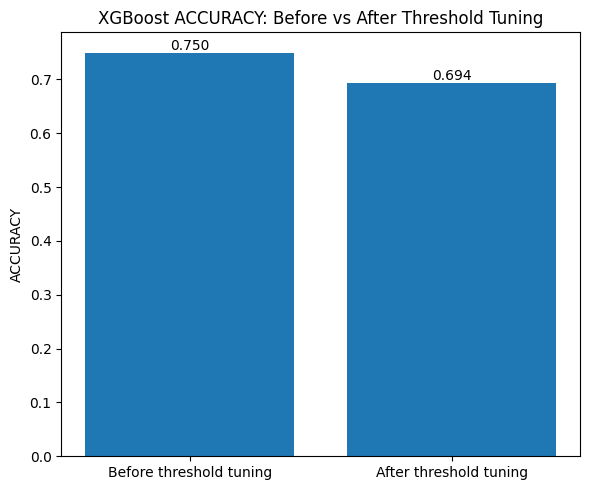

Saved: /content/drive/MyDrive/TELCO_CHURN_PROJECT/outputs/xgboost/xgboost_accuracy_before_vs_after_threshold.png


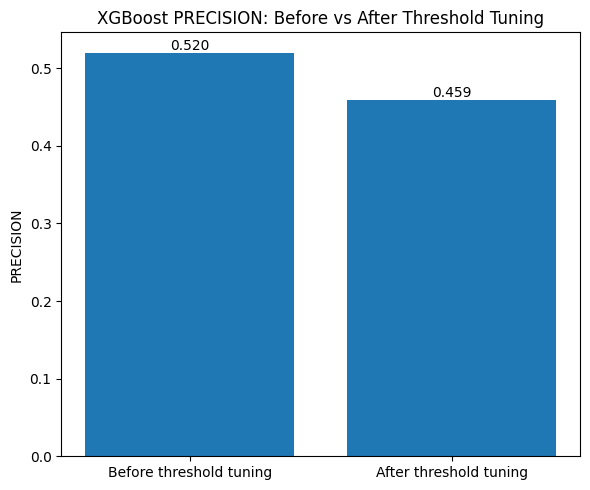

Saved: /content/drive/MyDrive/TELCO_CHURN_PROJECT/outputs/xgboost/xgboost_precision_before_vs_after_threshold.png


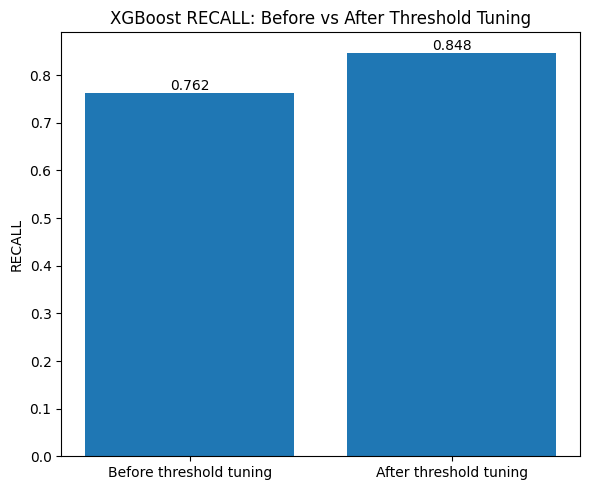

Saved: /content/drive/MyDrive/TELCO_CHURN_PROJECT/outputs/xgboost/xgboost_recall_before_vs_after_threshold.png


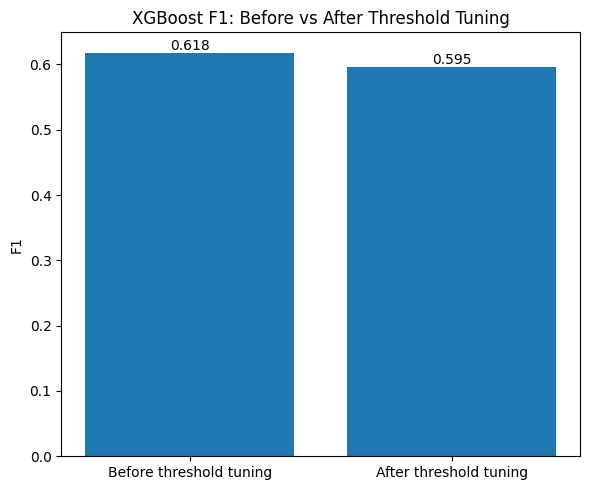

Saved: /content/drive/MyDrive/TELCO_CHURN_PROJECT/outputs/xgboost/xgboost_f1_before_vs_after_threshold.png


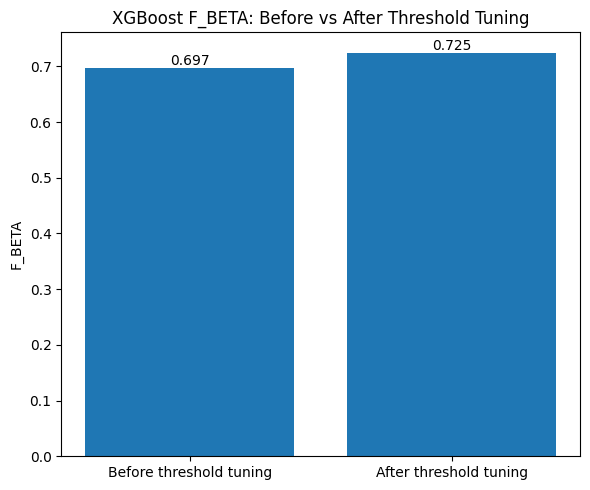

Saved: /content/drive/MyDrive/TELCO_CHURN_PROJECT/outputs/xgboost/xgboost_f_beta_before_vs_after_threshold.png


In [18]:
# =====================================================
# CHARTS: BEFORE vs AFTER THRESHOLD
# =====================================================
metrics = ["accuracy", "precision", "recall", "f1", "f_beta"]

for metric in metrics:
    before_val = summary_df[f"default_{metric}"].iloc[0]
    after_val = summary_df[f"best_{metric}"].iloc[0]

    plt.figure(figsize=(6, 5))
    bars = plt.bar(
        ["Before threshold tuning", "After threshold tuning"],
        [before_val, after_val]
    )

    plt.ylabel(metric.upper())
    plt.title(f"XGBoost {metric.upper()}: Before vs After Threshold Tuning")

    for bar in bars:
        height = bar.get_height()
        plt.text(
            bar.get_x() + bar.get_width() / 2,
            height,
            f"{height:.3f}",
            ha="center",
            va="bottom"
        )

    plt.tight_layout()
    save_path = OUTPUT_DIR / f"xgboost_{metric}_before_vs_after_threshold.png"
    plt.savefig(save_path, dpi=300, bbox_inches="tight")
    plt.show()
    print("Saved:", save_path)

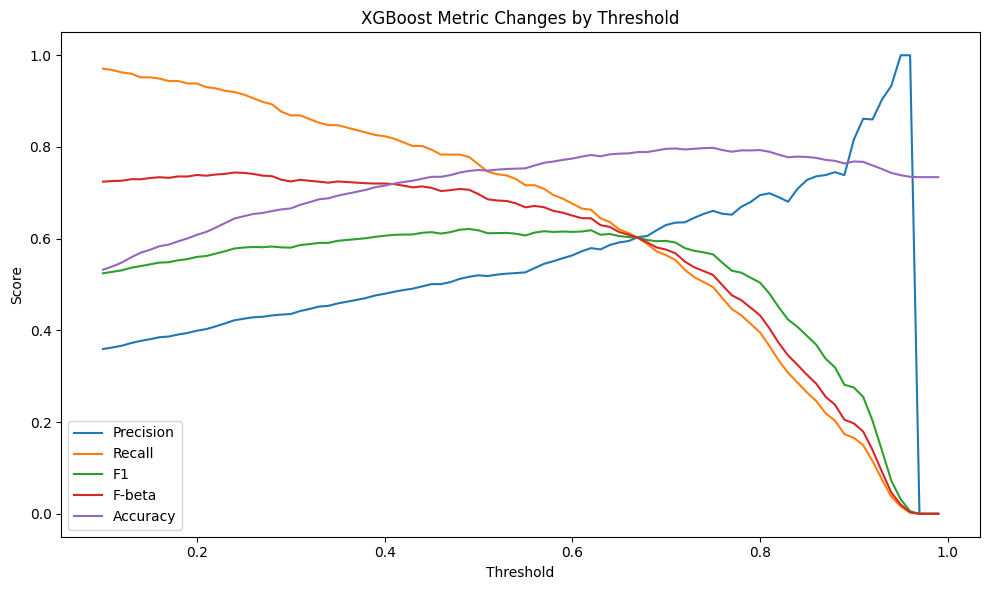

Saved: /content/drive/MyDrive/TELCO_CHURN_PROJECT/outputs/xgboost/xgboost_threshold_curves.png


In [19]:
# =====================================================
# THRESHOLD CURVES
# =====================================================
plt.figure(figsize=(10, 6))
plt.plot(threshold_df["threshold"], threshold_df["precision"], label="Precision")
plt.plot(threshold_df["threshold"], threshold_df["recall"], label="Recall")
plt.plot(threshold_df["threshold"], threshold_df["f1"], label="F1")
plt.plot(threshold_df["threshold"], threshold_df["f_beta"], label="F-beta")
plt.plot(threshold_df["threshold"], threshold_df["accuracy"], label="Accuracy")

plt.xlabel("Threshold")
plt.ylabel("Score")
plt.title("XGBoost Metric Changes by Threshold")
plt.legend()
plt.tight_layout()

curve_path = OUTPUT_DIR / "xgboost_threshold_curves.png"
plt.savefig(curve_path, dpi=300, bbox_inches="tight")
plt.show()

print("Saved:", curve_path)

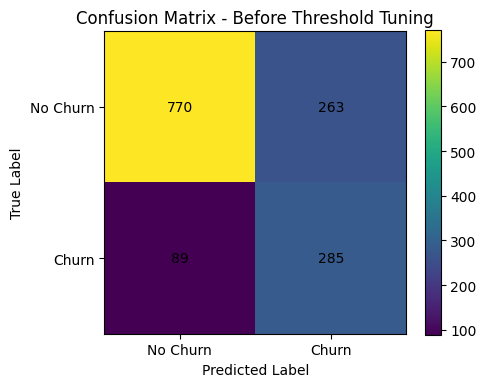

Saved: /content/drive/MyDrive/TELCO_CHURN_PROJECT/outputs/xgboost/xgboost_confusion_matrix_before_threshold.png


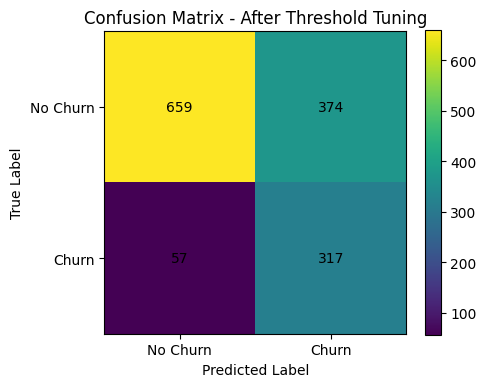

Saved: /content/drive/MyDrive/TELCO_CHURN_PROJECT/outputs/xgboost/xgboost_confusion_matrix_after_threshold.png


In [20]:
# =====================================================
# CONFUSION MATRIX BEFORE vs AFTER
# =====================================================
import matplotlib.pyplot as plt
import numpy as np

def plot_confusion_matrix(cm, title, save_path):
    cm = np.array(cm)

    plt.figure(figsize=(5, 4))
    plt.imshow(cm, interpolation="nearest")
    plt.title(title)
    plt.colorbar()
    tick_marks = np.arange(2)
    plt.xticks(tick_marks, ["No Churn", "Churn"])
    plt.yticks(tick_marks, ["No Churn", "Churn"])
    plt.xlabel("Predicted Label")
    plt.ylabel("True Label")

    for i in range(cm.shape[0]):
        for j in range(cm.shape[1]):
            plt.text(j, i, str(cm[i, j]), ha="center", va="center")

    plt.tight_layout()
    plt.savefig(save_path, dpi=300, bbox_inches="tight")
    plt.show()
    print("Saved:", save_path)

plot_confusion_matrix(
    default_result["cm"],
    "Confusion Matrix - Before Threshold Tuning",
    OUTPUT_DIR / "xgboost_confusion_matrix_before_threshold.png"
)

plot_confusion_matrix(
    best_threshold_result["cm"],
    "Confusion Matrix - After Threshold Tuning",
    OUTPUT_DIR / "xgboost_confusion_matrix_after_threshold.png"
)